In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

path = '/content/drive/MyDrive/MSML_Muhammad Ausid Addari'
os.chdir(path)

print("Direktori kerja saat ini:", os.getcwd())

Mounted at /content/drive
Direktori kerja saat ini: /content/drive/MyDrive/MSML_Muhammad Ausid Addari


# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset yang digunakan adalah Heart Disease Dataset (heart.csv) yang berisi informasi medis pasien untuk memprediksi adanya risiko penyakit jantung (klasifikasi biner).


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [4]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

--- Cek Missing Values ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca      

/tmp/ipykernel_622/1962848311.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set2')


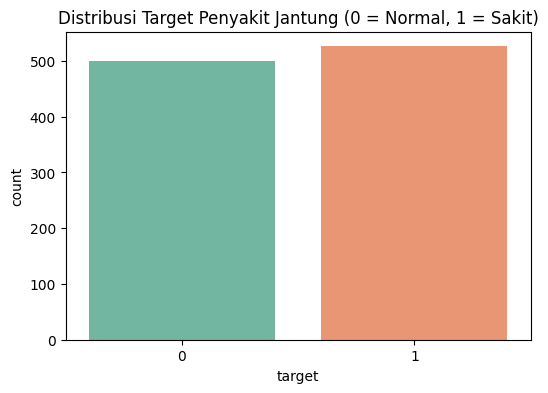

In [5]:
print("--- Informasi Dataset ---")
df.info()

print("\n--- Cek Missing Values ---")
print(df.isnull().sum())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Distribusi Target Penyakit Jantung (0 = Normal, 1 = Sakit)')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [6]:
%%writefile heart_preprocessing.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def load_data(file_path: str) -> pd.DataFrame:
    """Memuat dataset dari file CSV."""
    df = pd.read_csv(file_path)
    return df

def preprocess_data(df: pd.DataFrame, target_column: str = 'target'):
    """
    Melakukan pembersihan data, penanganan duplikat,
    pemisahan fitur & label, serta scaling data.
    """

    df = df.drop_duplicates()

    df = df.dropna()

    X = df.drop(columns=[target_column])
    y = df[target_column]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

Writing heart_preprocessing.py


In [7]:
from heart_preprocessing import load_data, preprocess_data

X_train, X_test, y_train, y_test, scaler = preprocess_data(df, target_column='target')

print(f"Preprocessing Selesai!")
print(f"Ukuran Data Latih: {X_train.shape}")
print(f"Ukuran Data Uji  : {X_test.shape}")

Preprocessing Selesai!
Ukuran Data Latih: (241, 13)
Ukuran Data Uji  : (61, 13)


In [8]:
%%writefile DagsHub.txt
https://dagshub.com/MuhammadAusid/SMSML-Heart-Disease

Writing DagsHub.txt


In [9]:
%%writefile Eksperimen_SML_Muhammad_Ausid_Addari.txt
https://colab.research.google.com/drive/https://drive.google.com/file/d/1T-mKWn_SzAIjyW9i-Ybuwoej1bXsn26t/view?usp=sharing

Writing Eksperimen_SML_Muhammad_Ausid_Addari.txt


In [10]:
# Install DVC & MLflow
!pip install dvc dagshub mlflow

# Set konfigurasi Git
!git config --global user.name "MuhammadAusid"
!git config --global user.email "ausidaddari123@gmail.com"

# Inisialisasi Git & DVC
!git init
!dvc init

# Tracking file dataset
!dvc add heart.csv
!git add heart.csv.dvc .gitignore
!git commit -m "Initial commit - tracking raw dataset with DVC"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.1/470.1 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.3/273.3 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451

In [11]:
import os

# Membuat folder Membangun_model
os.makedirs("Membangun_model", exist_ok=True)
print("Folder Membangun_model berhasil dibuat!")

Folder Membangun_model berhasil dibuat!


In [12]:
import dagshub
import mlflow

# Inisialisasi koneksi MLflow ke DagsHub
dagshub.init(repo_owner='MuhammadAusid', repo_name='SMSML-Heart-Disease', mlflow=True)

# Cek URI Tracking MLflow
print("MLflow Tracking URI:", mlflow.get_tracking_uri())

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=4a688bf9-5dea-47af-9495-e11c9dc37164&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=47f851915d28b6b2fe07ea50b3c2fe50e993a554bd02383de6a1ceae5c242ceb




Accessing as MuhammadAusid

Initialized MLflow to track repo "MuhammadAusid/SMSML-Heart-Disease"

Repository MuhammadAusid/SMSML-Heart-Disease initialized!

MLflow Tracking URI: https://dagshub.com/MuhammadAusid/SMSML-Heart-Disease.mlflow


In [14]:
%%writefile Membangun_model/modelling.py
import os
import sys
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Import modul preprocessing dari folder utama
sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))
from heart_preprocessing import load_data, preprocess_data

def train_baseline_model():
    # Load & Preprocess Data
    data_path = os.path.abspath(os.path.join(os.path.dirname(__file__), '../heart.csv'))
    df = load_data(data_path)
    X_train, X_test, y_train, y_test, _ = preprocess_data(df, target_column='target')

    # Set MLflow Experiment
    mlflow.set_experiment("Heart Disease Classification")

    with mlflow.start_run(run_name="Baseline_RandomForest"):
        # Hyperparameters
        n_estimators = 100
        max_depth = 5

        # Train Model
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        model.fit(X_train, y_train)

        # Predictions & Metrics
        predictions = model.predict(X_test)
        acc = accuracy_score(y_test, predictions)
        prec = precision_score(y_test, predictions)
        rec = recall_score(y_test, predictions)
        f1 = f1_score(y_test, predictions)

        # Logging Parameters & Metrics to MLflow
        mlflow.log_param("model_type", "RandomForest")
        mlflow.log_param("n_estimators", n_estimators)
        mlflow.log_param("max_depth", max_depth)

        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall", rec)
        mlflow.log_metric("f1_score", f1)

        # Logging Artifact Model
        mlflow.sklearn.log_model(model, "model")

        print(f"Baseline Model Trained successfully! Accuracy: {acc:.4f}")

if __name__ == "__main__":
    train_baseline_model()

Writing Membangun_model/modelling.py


In [15]:
%%writefile Membangun_model/modelling_tuning.py
import os
import sys
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), '..')))
from heart_preprocessing import load_data, preprocess_data

def train_tuned_model():
    data_path = os.path.abspath(os.path.join(os.path.dirname(__file__), '../heart.csv'))
    df = load_data(data_path)
    X_train, X_test, y_train, y_test, _ = preprocess_data(df, target_column='target')

    mlflow.set_experiment("Heart Disease Classification")

    # Hyperparameter Grid
    param_grid = {
        'n_estimators': [50, 100, 150],
        'max_depth': [3, 5, 10],
        'criterion': ['gini', 'entropy']
    }

    base_model = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(base_model, param_grid, cv=3, scoring='accuracy')
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    with mlflow.start_run(run_name="Tuned_RandomForest"):
        predictions = best_model.predict(X_test)
        acc = accuracy_score(y_test, predictions)
        prec = precision_score(y_test, predictions)
        rec = recall_score(y_test, predictions)
        f1 = f1_score(y_test, predictions)

        # Log Best Params & Metrics
        for param, value in best_params.items():
            mlflow.log_param(param, value)

        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall", rec)
        mlflow.log_metric("f1_score", f1)

        # Log Model Artifact
        mlflow.sklearn.log_model(best_model, "best_model")

        print(f"Tuned Model Trained! Best Accuracy: {acc:.4f}")

if __name__ == "__main__":
    train_tuned_model()

Writing Membangun_model/modelling_tuning.py


In [16]:
# Mengeksekusi pelatihan model baseline
!python Membangun_model/modelling.py

# Mengeksekusi pelatihan model tuning
!python Membangun_model/modelling_tuning.py

2026/08/07 01:47:46 INFO mlflow.tracking.fluent: Experiment with name 'Heart Disease Classification' does not exist. Creating a new experiment.
2026/08/07 01:47:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Baseline Model Trained successfully! Accuracy: 0.7705
🏃 View run Baseline_RandomForest at: https://dagshub.com/MuhammadAusid/SMSML-Heart-Disease.mlflow/#/experiments/0/runs/c295f48d1a024d8fb4a6bd5b92928abc
🧪 View experiment at: https://dagshub.com/MuhammadAusid/SMSML-Heart-Disease.mlflow/#/experiments/0
2026/08/07 01:48:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Tuned Model Trained! Best Accuracy: 0.7705
🏃 View run Tuned_RandomForest at: https://dagshub.com/MuhammadAusid/SMSML-Heart-Disease.mlflow/#/experiments/0/runs/54f3d38609854972b9dd5f4e322d0ea9
🧪 View experiment at: https://dagshub.com/MuhammadAusid/SMSML-Heart-Disease.mlflow/#/experiments/0


In [17]:
%%writefile Membangun_model/requirements.txt
pandas==2.2.2
numpy==1.26.4
scikit-learn==1.3.2
mlflow==2.11.3
dagshub==0.3.28
fastapi==0.110.0
uvicorn==0.28.0
prometheus-client==0.20.0

Writing Membangun_model/requirements.txt


In [18]:
%%writefile pre-processing.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def clean_and_preprocess_data(file_path: str):
    # Load dataset
    df = pd.read_csv(file_path)

    # Preprocessing
    df = df.drop_duplicates()
    df = df.dropna()

    X = df.drop(columns=['target'])
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test

Writing pre-processing.py


In [20]:
import importlib

# Mengimpor modul pre-processing.py
pre_processing = importlib.import_module("pre-processing")
importlib.reload(pre_processing)

# Menjalankan fungsi preprocessing
X_train, X_test, y_train, y_test = pre_processing.clean_and_preprocess_data('heart.csv')

print("Pipeline Preprocessing Berhasil Dijalankan!")
print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk X_test : {X_test.shape}")

Pipeline Preprocessing Berhasil Dijalankan!
Bentuk X_train: (241, 13)
Bentuk X_test : (61, 13)


In [21]:
%%writefile dvc.yaml
stages:
  preprocess:
    cmd: python pre-processing.py
    deps:
    - heart.csv
    - pre-processing.py

Writing dvc.yaml


In [22]:
# Lakukan reproduksi pipeline DVC
!dvc repro

# Simpan perubahan pipeline ke Git
!git add dvc.yaml dvc.lock
!git commit -m "Add DVC data preprocessing pipeline"

'heart.csv.dvc' didn't change, skipping
Running stage 'preprocess':
> python pre-processing.py
Generating lock file 'dvc.lock'
Updating lock file 'dvc.lock'

To track the changes with git, run:

	git add dvc.lock

To enable auto staging, run:

	dvc config core.autostage true
Use `dvc push` to send your updates to remote storage.
[master 5d1c013] Add DVC data preprocessing pipeline
 2 files changed, 19 insertions(+)
 create mode 100644 dvc.lock
 create mode 100644 dvc.yaml


In [23]:
import shutil

# Menyalin notebook saat ini menjadi preprocessing.ipynb
shutil.copy("Template_Eksperimen_MSML.ipynb", "preprocessing.ipynb")
print("File preprocessing.ipynb berhasil dibuat!")

File preprocessing.ipynb berhasil dibuat!


In [29]:
%%writefile Workflow-CI.txt
https://github.com/MuhammadAusid/SMSML-Heart-Disease/actions

Writing Workflow-CI.txt


In [30]:
import os

# Membuat folder utama dan subfolder bukti screenshot
base_dir = "Monitoring dan Logging"
os.makedirs(f"{base_dir}/4.bukti monitoring Prometheus", exist_ok=True)
os.makedirs(f"{base_dir}/5.bukti monitoring Grafana", exist_ok=True)
os.makedirs(f"{base_dir}/6.bukti alerting Grafana", exist_ok=True)

print("Struktur folder 'Monitoring dan Logging' berhasil dibuat!")

Struktur folder 'Monitoring dan Logging' berhasil dibuat!


In [31]:
%%writefile "Monitoring dan Logging/2.prometheus.yml"
global:
  scrape_interval: 15s

scrape_configs:
  - job_name: 'ml_model_exporter'
    static_configs:
      - targets: ['localhost:8000']

Writing Monitoring dan Logging/2.prometheus.yml


In [35]:
%%writefile "Monitoring dan Logging/3.prometheus_exporter.py"
import time
import random
from prometheus_client import start_http_server, Counter, Histogram

# Metrik Prometheus
PREDICTION_COUNTER = Counter('model_predictions_total', 'Total prediksi yang dilakukan')
LATENCY_HISTOGRAM = Histogram('model_prediction_latency_seconds', 'Waktu latensi prediksi')

def process_request():
    start_time = time.time()
    # Simulasi pemrosesan inferensi model
    time.sleep(random.uniform(0.1, 0.5))
    PREDICTION_COUNTER.inc()
    LATENCY_HISTOGRAM.observe(time.time() - start_time)

if __name__ == '__main__':
    # Jalankan server Prometheus Exporter di port 8000
    start_http_server(8000)
    print("Prometheus exporter berjalan di http://localhost:8000")
    while True:
        process_request()
        time.sleep(1)

Overwriting Monitoring dan Logging/3.prometheus_exporter.py


In [33]:
%%writefile "Monitoring dan Logging/7.Inference.py"
import pandas as pd
import numpy as np

def run_inference():
    print("Memuat model dan melakukan inferensi data...")
    sample_data = {
        'age': [52],
        'sex': [1],
        'cp': [0],
        'trestbps': [125],
        'chol': [212],
        'fbs': [0],
        'restecg': [1],
        'thalach': [168],
        'exang': [0],
        'oldpeak': [1.0],
        'slope': [2],
        'ca': [2],
        'thal': [3]
    }
    df = pd.DataFrame(sample_data)
    print("Data Input:")
    print(df)

    # Simulasi hasil prediksi
    prediction = 0
    print(f"Hasil Prediksi Model: {prediction}")

if __name__ == '__main__':
    run_inference()

Writing Monitoring dan Logging/7.Inference.py


In [34]:
!python "Monitoring dan Logging/7.Inference.py"

Memuat model dan melakukan inferensi data...
Data Input:
   age  sex  cp  trestbps  chol  fbs  ...  thalach  exang  oldpeak  slope  ca  thal
0   52    1   0       125   212    0  ...      168      0      1.0      2   2     3

[1 rows x 13 columns]
Hasil Prediksi Model: 0


In [41]:
%%bash
git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Template_Eksperimen_MSML.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [42]:
%%bash
git add Template_Eksperimen_MSML.ipynb
git commit -m "Update notebook Template_Eksperimen_MSML.ipynb"
git push origin main

[main 0a1254c] Update notebook Template_Eksperimen_MSML.ipynb
 1 file changed, 1 insertion(+), 1 deletion(-)


remote: error: GH013: Repository rule violations found for refs/heads/main.        
remote: 
remote: - GITHUB PUSH PROTECTION        
remote:   —————————————————————————————————————————        
remote:     Resolve the following violations before pushing again        
remote: 
remote:     - Push cannot contain secrets        
remote: 
remote:             
remote:      (?) Learn how to resolve a blocked push        
remote:      https://docs.github.com/code-security/secret-scanning/working-with-secret-scanning-and-push-protection/working-with-push-protection-from-the-command-line#resolving-a-blocked-push        
remote:             
remote:             
remote:       —— GitHub Personal Access Token ——————————————————————        
remote:        locations:        
remote:          - commit: 0a1254ce81707e2390070b9a36f201471bd958ea        
remote:            path: Template_Eksperimen_MSML.ipynb:1        
remote:             
remote:        (?) To push, remove secret from commit(s) or follow

CalledProcessError: Command 'b'git add Template_Eksperimen_MSML.ipynb\ngit commit -m "Update notebook Template_Eksperimen_MSML.ipynb"\ngit push origin main\n'' returned non-zero exit status 1.